# **Fase de Evaluación: Modelo Base (Baseline) con ML Clásico (Random Forest)**

**Objetivo del Notebook:**
Implementar un modelo predictivo tradicional basado en frecuencia de palabras (TF-IDF + Random Forest) para la clasificación de logs de pasarelas de pago.

**Justificación Metodológica (Punto 4):**
Este notebook cubre el ciclo completo de Machine Learning (EDA, Limpieza, Entrenamiento y Evaluación). Su propósito principal en el marco del proyecto AIOps es establecer una métrica base. Al final, someteremos este modelo a una **Prueba de Estrés (Ruido Sintáctico)** para demostrar empíricamente la fragilidad de los algoritmos clásicos frente a variaciones de código en producción (Data Drift), justificando de manera contundente la superioridad de arquitecturas profundas como BERT.

In [2]:
# ---------------------------------------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS Y CARGA SEGURA DEL DATASET
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")

# Nombre esperado del archivo
file_name = 'dataset_hibrido_final_AIOps.csv'

# Verificación y carga interactiva si el archivo no existe en el entorno
if not os.path.exists(file_name):
    print(f"[!] El archivo '{file_name}' no se detectó en el entorno de Colab.")
    print("[!] Por favor, selecciona y sube el archivo usando el botón a continuación:")
    uploaded = files.upload() # Esto abrirá el cuadro de diálogo para cargar el archivo

# Intentamos cargar el dataset asegurando que exista
if os.path.exists(file_name):
    df = pd.read_csv(file_name)
    print(f"\n[ÉXITO] Dataset '{file_name}' cargado correctamente.")
    print(f"Total de registros a procesar: {df.shape[0]}")
    print(f"Total de columnas: {df.shape[1]}")
else:
    # Si el usuario cancela la subida, detenemos la ejecución para evitar el NameError
    raise FileNotFoundError("El dataset no fue cargado. No se puede continuar con la ejecución.")

[!] El archivo 'dataset_hibrido_final_AIOps.csv' no se detectó en el entorno de Colab.
[!] Por favor, selecciona y sube el archivo usando el botón a continuación:


Saving dataset_hibrido_final_AIOps.csv to dataset_hibrido_final_AIOps.csv

[ÉXITO] Dataset 'dataset_hibrido_final_AIOps.csv' cargado correctamente.
Total de registros a procesar: 8558
Total de columnas: 5


## **2. Análisis Exploratorio de Datos (EDA)**
Antes de procesar los datos, es imperativo comprender la distribución de nuestras clases para identificar posibles desbalances que puedan afectar el rendimiento del modelo.

,timestamp,operation,URL,http_status_code,Log_Message_Clean
0,2026-02-16T11:59:43.828602353+06:00,count,/api/pagos/pse,429,[warn] rate limit exceeded for user_id=[user_i...
1,2026-02-16T11:59:37.816303101+06:00,sum,/api/billetera/consulta_saldo,500,[error] fatal exception in /api/billetera/cons...
2,2026-02-16T12:00:12.145068983+06:00,count,/api/pagos/pse,200,[info] transaction successful for endpoint /ap...
3,2026-02-16T11:52:08.027514445+06:00,count,/api/billetera/consulta_saldo,200,[info] transaction successful for endpoint /ap...
4,2026-02-16T11:48:12.483245639+06:00,sum,/api/billetera/consulta_saldo,429,[warn] rate limit exceeded for user_id=[user_i...



--- Distribución de Códigos de Estado HTTP ---
http_status_code
200    4279
429     879
504     850
401     849
403     844
500     838
503      19
Name: count, dtype: int64


/tmp/ipykernel_3748/286462888.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette=['#4CAF50', '#F44336'])


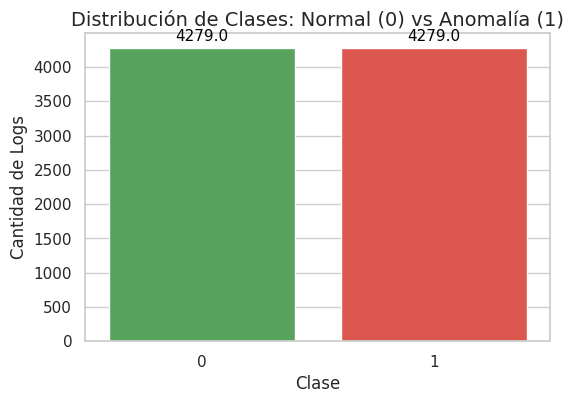

In [3]:
# ---------------------------------------------------------
# 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ---------------------------------------------------------

# Mostramos las primeras 5 filas para entender la estructura
display(df.head())

# Verificamos la distribución de los códigos de estado HTTP
print("\n--- Distribución de Códigos de Estado HTTP ---")
print(df['http_status_code'].value_counts())

# Generamos la variable objetivo 'label' para simplificar el problema a clasificación binaria:
# Asumimos: 200 (Éxito) = 0 (Normal) | Diferente a 200 (Ej. 4xx, 5xx) = 1 (Anomalía)
df['label'] = df['http_status_code'].apply(lambda x: 0 if x == 200 else 1)

# Visualización del balance de clases
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=df, palette=['#4CAF50', '#F44336'])
plt.title('Distribución de Clases: Normal (0) vs Anomalía (1)', fontsize=14)
plt.xlabel('Clase', fontsize=12)
plt.ylabel('Cantidad de Logs', fontsize=12)

# Añadir etiquetas de datos en las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

## **3. Limpieza de Texto y Preprocesamiento**
Los modelos clásicos basados en `TF-IDF` son muy sensibles a caracteres irrelevantes, marcas de tiempo e IPs únicas. Si no limpiamos estos datos, el vocabulario crecerá innecesariamente (maldición de la dimensionalidad), reduciendo la precisión del modelo.

In [4]:
# ---------------------------------------------------------
# 3. LIMPIEZA DE DATASET
# ---------------------------------------------------------

def clean_log_text(text):
    """
    Función para estandarizar el texto del log eliminando ruido no semántico.
    """
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'\b(?:[0-9]{1,3}\.){3}[0-9]{1,3}\b', ' <IP> ', text)
    text = re.sub(r'\d{2}:\d{2}:\d{2}', ' <TIME> ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Limpiando corpus de logs...")
# Aplicamos la limpieza directamente a la columna correcta
df['Log_Message_Processed'] = df['Log_Message_Clean'].apply(clean_log_text)

print("Limpieza completada. Ejemplo de log procesado:")
print(df['Log_Message_Processed'].iloc[0])

# Separación final de características (X) y variable objetivo (y)
X = df['Log_Message_Processed']
y = df['label']

Limpiando corpus de logs...
Limpieza completada. Ejemplo de log procesado:
warn rate limit exceeded for user_id user_id dropping request at api pagos pse


## **4. Vectorización y Entrenamiento del Modelo (Random Forest)**
Utilizamos `TfidfVectorizer` para convertir el texto limpio en vectores numéricos. Posteriormente, entrenamos un ensamblado de árboles de decisión (`Random Forest`) para establecer nuestro baseline de rendimiento con datos limpios y estructurados.

Entrenando modelo Random Forest...
Entrenamiento finalizado.

--------------------------------------------------
 RENDIMIENTO DEL MODELO CLÁSICO (DATOS IDEALES) 
--------------------------------------------------
              precision    recall  f1-score   support

Normal (200)       1.00      1.00      1.00       856
    Anomalía       1.00      1.00      1.00       856

    accuracy                           1.00      1712
   macro avg       1.00      1.00      1.00      1712
weighted avg       1.00      1.00      1.00      1712



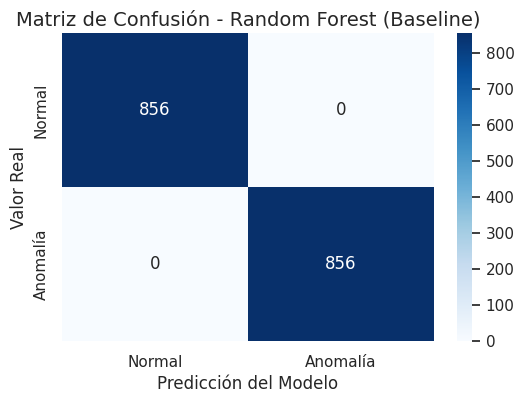

In [5]:
# ---------------------------------------------------------
# 4. ENTRENAMIENTO Y EVALUACIÓN CLÁSICA
# ---------------------------------------------------------

# Dividimos los datos en conjunto de Entrenamiento (80%) y Prueba (20%)
# Usamos stratify=y para mantener la proporción de anomalías en ambas particiones
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Vectorización TF-IDF limitando el vocabulario a las 1000 palabras más importantes
vectorizer = TfidfVectorizer(max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Entrenando modelo Random Forest...")
# Instanciamos y entrenamos el modelo
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_vec, y_train)
print("Entrenamiento finalizado.\n")

# Predicciones
y_pred = rf_model.predict(X_test_vec)

# Tablas de Métricas (Requisito del Punto 4)
print("-" * 50)
print(" RENDIMIENTO DEL MODELO CLÁSICO (DATOS IDEALES) ")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=['Normal (200)', 'Anomalía']))

# Visualización de la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalía'], yticklabels=['Normal', 'Anomalía'])
plt.title('Matriz de Confusión - Random Forest (Baseline)', fontsize=14)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

## **5. Prueba de Estrés: Data Drift por Nuevo Microservicio (Out-of-Distribution)**

**Justificación del Experimento:**
En las evaluaciones iniciales, el modelo clásico logró un 100% de precisión. Sin embargo, este rendimiento perfecto suele ser un espejismo en Machine Learning provocado por un fenómeno conocido como **Shortcut Learning (Aprendizaje por Atajos)**. El modelo, en lugar de "entender" qué es un error, simplemente memorizó palabras estáticas asociadas a las fallas de ese momento específico en el tiempo.

**El Escenario Productivo (La vulnerabilidad del ML Clásico):**
En un entorno AIOps de misión crítica (pasarelas de pago), los ecosistemas evolucionan mediante prácticas CI/CD. El escenario más común es la liberación a producción de un **nuevo microservicio**. Este nuevo componente introduce un vocabulario de logs completamente nuevo (ej. usa términos como `deadlock`, `panic` o `latency spike` en lugar del clásico `error`).

**Objetivo de esta celda:**
Vamos a simular el despliegue de un nuevo microservicio inyectando datos sintéticos (*Out-of-Distribution*). Dado que el vectorizador `TF-IDF` es un modelo estático basado en frecuencia (Bag of Words), se enfrentará al problema de **Out-Of-Vocabulary (OOV)**: no reconocerá las nuevas palabras, convirtiendo los logs críticos en vectores vacíos (ceros).

Al ejecutar esta prueba, observaremos el **colapso predictivo** del modelo clásico, demostrando empíricamente que los enfoques estadísticos generan una alta deuda técnica en entornos dinámicos y justificando la implementación de arquitecturas **Transformers (BERT)**, las cuales utilizan atención bidireccional para comprender la semántica del riesgo, sin importar si el vocabulario exacto cambia.

Simulando el paso a producción de un nuevo Microservicio de Pagos...

 RENDIMIENTO BAJO ESTRÉS (NUEVO MICROSERVICIO / DATA DRIFT) 
              precision    recall  f1-score   support

Normal (200)       0.00      0.00      0.00       900
    Anomalía       0.50      1.00      0.67       900

    accuracy                           0.50      1800
   macro avg       0.25      0.50      0.33      1800
weighted avg       0.25      0.50      0.33      1800


[!] ALERTA CRÍTICA: El modelo clásico sufrió una degradación del 33.33% frente al nuevo entorno.


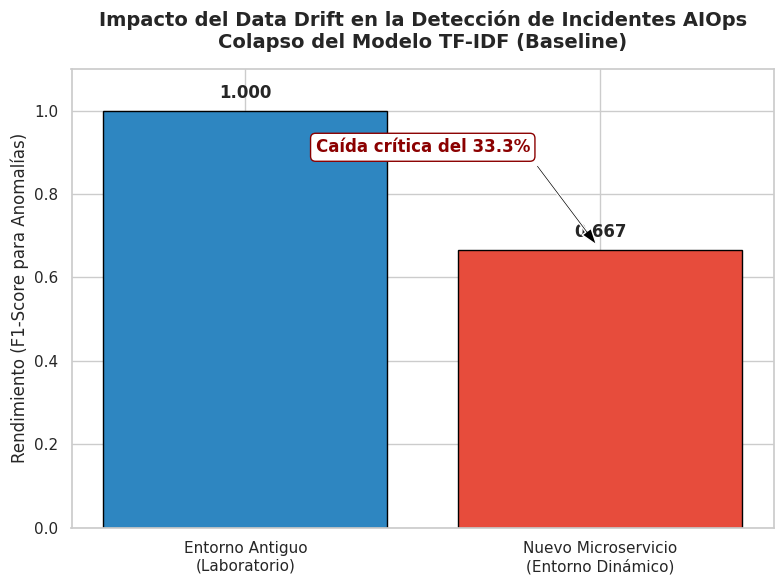

In [6]:
# ---------------------------------------------------------
# 5. PRUEBA DE ESTRÉS: DATA DRIFT POR NUEVO MICROSERVICIO (OUT-OF-DISTRIBUTION)
# ---------------------------------------------------------
import pandas as pd

print("Simulando el paso a producción de un nuevo Microservicio de Pagos...")
# En AIOps, la liberación de nuevo software trae nuevas estructuras gramaticales de logs.
# Generamos un dataset sintético con vocabulario que el TF-IDF nunca ha visto en entrenamiento.

logs_sinteticos = [
    # --- Comportamiento Normal (Clase 0) ---
    "[trace] auth token validated successfully for crypto gateway tx_id",
    "[debug] health check passed for downstream core bank api",
    "[trace] new user session established and secured via oauth2",

    # --- Anomalías Críticas (Clase 1) ---
    "[alert] database deadlock detected during bulk commit transaction",
    "[crit] severe latency spike in external credit card processor",
    "[panic] out of memory exception in worker node container crash"
] * 300 # Multiplicamos para tener 1800 registros y significancia estadística

# Etiquetas reales: 3 normales (0), 3 anomalías (1), repetidas 300 veces
y_nuevo_real = [0, 0, 0, 1, 1, 1] * 300

df_nuevo = pd.DataFrame({'log_message': logs_sinteticos, 'label': y_nuevo_real})

# 1. Limpiamos los logs con la misma función
df_nuevo['Log_Message_Processed'] = df_nuevo['log_message'].apply(clean_log_text)

# 2. Vectorizamos: El TF-IDF buscará las palabras que aprendió en la Fase 4.
# Como el vocabulario es nuevo, las matrices estarán compuestas mayormente de ceros.
X_nuevo_vec = vectorizer.transform(df_nuevo['Log_Message_Processed'])

# 3. Predicción del modelo clásico sobre el nuevo entorno productivo
y_pred_nuevo = rf_model.predict(X_nuevo_vec)

print("\n" + "=" * 65)
print(" RENDIMIENTO BAJO ESTRÉS (NUEVO MICROSERVICIO / DATA DRIFT) ")
print("=" * 65)
print(classification_report(y_nuevo_real, y_pred_nuevo, target_names=['Normal (200)', 'Anomalía'], zero_division=0))

# Cálculos para la gráfica
f1_clean = f1_score(y_test, y_pred, pos_label=1)
f1_drift = f1_score(y_nuevo_real, y_pred_nuevo, pos_label=1)

degradacion = ((f1_clean - f1_drift) / f1_clean) * 100 if f1_clean > 0 else 0.0

print(f"\n[!] ALERTA CRÍTICA: El modelo clásico sufrió una degradación del {degradacion:.2f}% frente al nuevo entorno.")

# --- GENERACIÓN DE LA GRÁFICA PARA EL DOCUMENTO DE TESIS ---
plt.figure(figsize=(8, 6))
bars = plt.bar(['Entorno Antiguo\n(Laboratorio)', 'Nuevo Microservicio\n(Entorno Dinámico)'],
               [f1_clean, f1_drift],
               color=['#2E86C1', '#E74C3C'],
               edgecolor='black')

plt.title('Impacto del Data Drift en la Detección de Incidentes AIOps\nColapso del Modelo TF-IDF (Baseline)',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Rendimiento (F1-Score para Anomalías)', fontsize=12)
plt.ylim(0, 1.1)

# Agregar los valores exactos encima de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Agregar flecha y porcentaje de degradación
if degradacion > 0:
    y_arrow_start = f1_clean - 0.1 if f1_clean - 0.1 > f1_drift else f1_clean
    plt.annotate(f'Caída crítica del {degradacion:.1f}%',
                 xy=(1, f1_drift), xytext=(0.5, y_arrow_start),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                 fontsize=12, ha='center', color='darkred', fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=1))

plt.tight_layout()
plt.show()